# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3792s 22us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

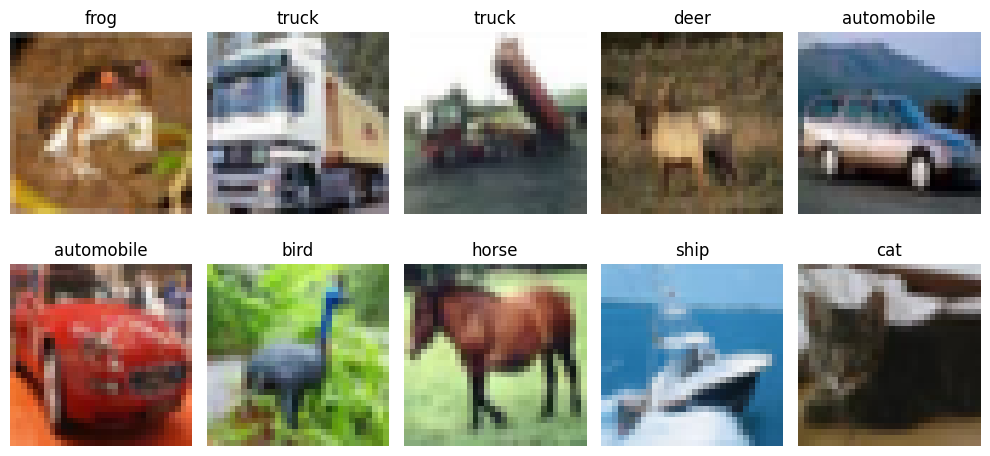

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2714 - loss: 1.9986 - val_accuracy: 0.3394 - val_loss: 1.8499
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3177 - loss: 1.8732 - val_accuracy: 0.3592 - val_loss: 1.7851
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.3399 - loss: 1.8147 - val_accuracy: 0.3770 - val_loss: 1.7374
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.3530 - loss: 1.7723 - val_accuracy: 0.3900 - val_loss: 1.7412
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3620 - loss: 1.7509 - val_accuracy: 0.4034 - val_loss: 1.7019
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3674 - loss: 1.7375 - val_accuracy: 0.4160 - val_loss: 1.6721
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3806 - loss: 1.7102 - val_accuracy: 0.4174 - val_loss: 1.6613
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3811 - loss: 1.7048 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4423 - loss: 1.5793
ANN Test Accuracy: 0.4422999918460846


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 130ms/step - accuracy: 0.4702 - loss: 1.4847 - val_accuracy: 0.5734 - val_loss: 1.2100
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.6130 - loss: 1.1109 - val_accuracy: 0.6248 - val_loss: 1.0387
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 127ms/step - accuracy: 0.6685 - loss: 0.9537 - val_accuracy: 0.6218 - val_loss: 1.0849
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7090 - loss: 0.8341 - val_accuracy: 0.7084 - val_loss: 0.8428
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.7392 - loss: 0.7435 - val_accuracy: 0.7234 - val_loss: 0.8211
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.7658 - loss: 0.6722 - val_accuracy: 0.7196 - val_loss: 0.8627
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - accuracy: 0.7872 - loss: 0.6059 - val_accuracy: 0.7006 - val_loss: 0.9277
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.8078 - los

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7136 - loss: 1.2672
CNN Test Accuracy: 0.7135999798774719


## 📈 Compare Learning Curves

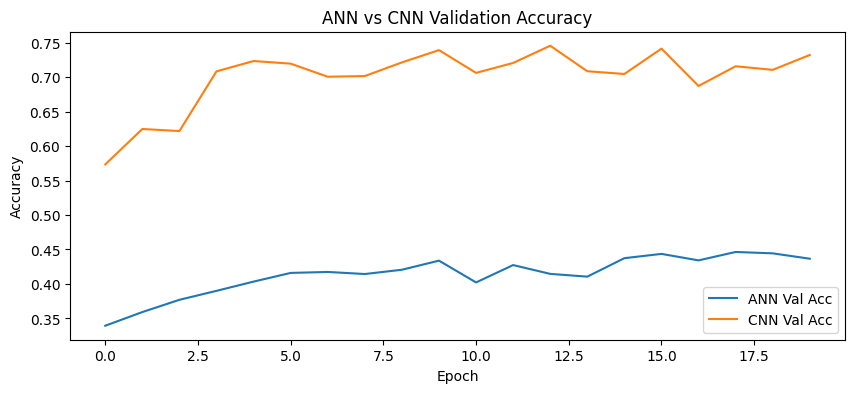

In [11]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)


aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("Augmented CNN Test Accuracy:", aug_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 98ms/step - accuracy: 0.3647 - loss: 1.7297 - val_accuracy: 0.4918 - val_loss: 1.4047
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.4641 - loss: 1.4842 - val_accuracy: 0.5022 - val_loss: 1.3584
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.5024 - loss: 1.3913 - val_accuracy: 0.5694 - val_loss: 1.1848
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - accuracy: 0.5275 - loss: 1.3286 - val_accuracy: 0.5868 - val_loss: 1.1556
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.5466 - loss: 1.2768 - val_accuracy: 0.6142 - val_loss: 1.0926
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5567 - loss: 1.2489 - val_accuracy: 0.5974 - val_loss: 1.1320
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5690 - loss: 1.2292 - val_accuracy: 0.6000 - val_loss: 1.1205
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.5745 - loss: 1.2010 - 

# 📊 Final Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Data Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4423
1,CNN,0.7136
2,CNN + Data Augmentation,0.6791


# Conclusion

In this project, we developed and compared image classification models on the CIFAR-10 dataset using both Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN).

The ANN model achieved a test accuracy of **44.23%**, demonstrating that fully connected networks struggle to capture the spatial features present in images.

The CNN model significantly outperformed the ANN, achieving a test accuracy of **71.36%** by effectively learning hierarchical image features through convolution and pooling operations.

A CNN with data augmentation achieved a test accuracy of **67.91%**. Although its accuracy was slightly lower in this experiment, data augmentation helps improve model robustness and generalization by exposing the model to more diverse training samples. With longer training or further hyperparameter tuning, its performance can potentially surpass the standard CNN.

Overall, this project highlights the importance of choosing appropriate neural network architectures for computer vision tasks and demonstrates that CNNs are far more effective than traditional ANNs for image classification.